# Tutorial 12: Cobalt L-edge Energy Sweep

This notebook keeps the sample, object-hole aperture, reference holes, illumination, and magnetic pattern fixed, then simulates Fourier transform holography at several photon energies across the Cobalt L3 and L2 edges.

The main diagnostics are:

- `CR` and `CL` exit waves at each energy;
- the complex XMCD exit-wave image `log(exit_CR / exit_CL)` in the object-hole ROI;
- XMCD amplitude and phase spectra from positive/negative magnetic-domain averages;
- ideal and detected holograms;
- FTH reconstructions cropped to the object-hole ROI;
- total hologram intensity as a function of photon energy.

The default grid is deliberately small enough for interactive use. Increase `detector_shape`, `energy_values_eV`, or enable multislice propagation once the workflow is clear.


In [1]:
import gc
import sys
from pathlib import Path
from types import SimpleNamespace

# Make the repository's src-layout packages importable without installing them.
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src" / "scattering_calculator").is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError("Could not find src/scattering_calculator above the notebook working directory")
src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import h5py
import matplotlib.pyplot as plt

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams["figure.constrained_layout.use"] = True

from scattering_calculator.sample_generator import pattern_generator
from scattering_calculator.simulation_pipelines import simulation_configuration as sim
from fomocid import DATA_ROOT



## 1. User Controls

The geometry below is fixed for the whole sweep. Only `energy` changes inside the loop.

`RUN_ENERGY_SWEEP=False` lets you inspect the notebook quickly without starting the simulations. Set it to `True` to generate the energy-dependent arrays.

Set `FIX_MASK_ILLUMINATION=True` to propagate the holographic mask and SiN at `mask_illumination_energy_eV` once per polarization. The resulting complex illumination immediately before the film is reused unchanged across the sweep, including its attenuation and phase. Only layers after SiN are then simulated at each swept energy; `propagate=True/False` controls this film stage independently. With the option disabled, the original full-stack behavior is retained.

This freezes the mask's energy dependence. Film optical constants and wavelength still change with the swept energy, so film diffraction can remain energy dependent when `propagate=True`. The mask reference energy is independent of the mesh and detector reference energy. Rerun the sweep cell after changing controls to regenerate the cached fields. Saved runs include these fields and the selected mode.


In [12]:
4//4

1

In [13]:

RUN_ENERGY_SWEEP = True
HDF5_BASE_PATH = (
    DATA_ROOT
    / "Data"
    / "fomocid"
    / "12_cobalt_l_edge_energy_sweep"
    / "cobalt_l_edge_energy_sweep.h5"
)
# When the sweep is disabled, set this to the saved run you want to load.
HDF5_OUTPUT_PATH = HDF5_BASE_PATH


pols=["CR","CL"]
# Energies spanning the Co L3 edge near 778 eV and the L2 edge near 793 eV.
energy_values_eV = np.arange(773.0, 803.0, 0.5)
all_energy_values_eV = np.array([720,730,740,750,770,775,777,777.5,778,778.5,778.9,779.5,780,780.5,784,787,788.3,789,790,791,794,800,810,820])
all_energy_values_eV = np.array([779.5,780,784,787,788.3])
energy_stride = 1  # Run every energy; completed energies are streamed to HDF5.
energy_values_eV = all_energy_values_eV[::energy_stride]
# Reference energy always sets the fixed sample mesh.
reference_energy_eV = 780
# True: project every energy at reference_energy_eV for a common image scale.
# False: detector projection follows each swept energy (physical scaling).
FIX_DETECTOR_PROJECTION_ENERGY = True

# Use Jones for the full polarization interaction. Scalar is faster and can be
# used when the selected polarization is an eigenmode of the local interaction.
propagator_method = "Scalar"
scalar_refractive_index_lazy = True

# Jones-only is fast and already includes the rank-zero longitudinal phase.
# Set propagate=True to include multislice free-space propagation between layers.
propagate = True
# Optional two-stage experiment: freeze the complex field just after SiN.
# The mask stage ALWAYS propagates; propagate above then controls only the film.
FIX_MASK_ILLUMINATION = True
mask_illumination_energy_eV = 780.0
jones_apply_zero_order_phase = True
multislice_propagation_roi = True
multislice_propagation_roi_padding_px = 15
multislice_propagation_roi_merge_overlaps = False
propagation_padding_px = 10
propagation_padding_mode = "edge"
propagation_absorber_width_px = 5
propagation_absorber_strength = 6.0
propagation_absorber_profile = "cosine"

# Detector and beam settings. The sample mesh is fixed from reference_energy_eV.
detector_shape = (1024,1024)
detector_center = tuple(np.array(detector_shape) // 2)
# oversampling=2 creates a 2048x2048 sample grid; oversampling=4 creates a
# 4096x4096 sample grid and can exceed RAM during a single energy point.
oversampling = 2
ignore_flat_detector_curvature = False
photon_flux = 5e8
coherence_length = (25000e-6, 25000e-6)

# Fixed sample, aperture, illumination, and magnetic texture.
recipe = "[Au(200)/Cr(5)]x20/SiN(0.5)/Co(20)Pt(20)"
#recipe = "[Au(200)/Cr(5)]x20/SiN(0.5)/Pt(20)"
recipe = "[Au(200)/Cr(5)]x20/SiN(0.5)/vacuum(1)"


recipe = "[Au(50)/Cr(10)]x20/SiN(0.5)/Co(20)Pt(20)"

#recipe = "[Au(45)/Cr(5)]x60/SiN(0.5)/Co(20)Pt(20)"


sample_name = "cobalt_l_edge_energy_sweep_tutorial"
illumination_center = (0.0, 0.0)
illumination_focus_distance = 1e-3
illumination_fwhm = 50.e-6
illumination_alpha_beam = (0.0, 0.0)

aperture_types = ["OH", "RH", "RH"]
aperture_radii = [250e-9, 30e-9, 10e-9]
aperture_centers = [(0.0, 0.0), (-700e-9, -700e-9), (700e-9, -700e-9)]
aperture_sigmas = [4e-9, 2e-9, 2e-9]
aperture_angles = [0.0, 0.0, 0.0]
aperture_ellipticities = [1.0, 1.0, 1.0]
aperture_roughnesses = [0.0, 0.02, 0.02]
aperture_roughness_modes = [(0, 0), (3, 10), (3, 10)]
aperture_seeds = [1, 2, 3]
aperture_top_radius_factors = [3.,5., 5.]

# The object image in an FTH reconstruction is not centered at the origin.
# It is displaced by the reference-hole/object-hole separation. Use the first
# RH by default; flip the sign if you want the conjugate/twin object image.
fth_reference_aperture_index = 1
fth_reconstruction_shift_sign = 1

# Domain averages ignore pixels close to a domain wall, where mz is neither
# clearly positive nor clearly negative after smoothing.
xmcd_domain_threshold = 0.9

pattern_type = "binary_labyrinth_pattern"
pattern_config = {
    "stripe_width": 135e-9,
    "sigma": 4e-9,
    "domain_conversion": "soft",
    "softness": 1.2,
    "n_steps": 60,
    "seed": 4,
    "use_gpu": False,
}


## 2. Build The Fixed Sample Mesh And Magnetic Pattern

The detector geometry and reference energy define a fixed sample-plane pixel size. The same physical magnetic pattern is reused at every energy, so changes in the result come from the energy-dependent refractive indices rather than from a different random sample.


In [14]:
def make_xray_config(energy_eV, pol=pols[0]):
    xray_config = sim.XRayConfig(
        energy=float(energy_eV),
        photon_flux=photon_flux,
        pol=pol,
        coherence_length=coherence_length,
    )
    xray_config.setup()
    return xray_config


def make_detector_config(noise_seed=20):
    beamstop_config = sim.BeamstopConfig(
        bs_method="circular",
        bs_detector_distance=0.010,
        bs_center=detector_center,
        bs_config={
            "radius": 90e-6,
            "sigma": 1e-6,
            "wire_width": 5e-6,
            "wire_bend": 30e-6,
            "angle": np.deg2rad(25),
            "antialias": 2,
            "seed": 4,
        },
    )
    detector_config = sim.DetectorConfig(
        shape=detector_shape,
        pixel_size=20e-6,
        sample_to_detector_distance=0.10,
        detector_center=detector_center,
        detector_params={
            "readout_noise_average": 10,
            "readout_noise_sigma": 1,
            "detector_threshold": 64e3,
            "counts_per_photon": 200,
            "quantum_efficiency": 1.0,
            "noise_seed": int(noise_seed),
        },
        measurement_config={
            "number_frames": 50,
            "max_counts_per_image": 64e3,
            "exposure_time": 1.0,
        },
        beamstop_config=beamstop_config,
        use_detector_pixel_footprint=True,
        detector_pixel_footprint_samples=oversampling,
        ignore_flat_detector_curvature=ignore_flat_detector_curvature,
    )
    detector_config.setup()
    return detector_config


reference_xray_config = make_xray_config(reference_energy_eV)
reference_detector_config = make_detector_config()
real_space_pixel_size = reference_detector_config.calc_realspace_resolution(reference_xray_config.beam_params) / oversampling
sample_shape = np.array([0, oversampling * detector_shape[0], oversampling * detector_shape[1]], dtype=int)

magnetic_pattern_config = sim.MagneticPatternConfig(
    pattern_type_method=pattern_type,
    shape=tuple(sample_shape[1:]),
    real_space_pixel_size=real_space_pixel_size,
    pattern_config=pattern_config,
)
magnetic_pattern_config.create_pattern()
magnetic_pattern_2d = np.asarray(magnetic_pattern_config.magnetic_pattern, dtype=np.float32)

print(f"Fixed sample pixel size: {real_space_pixel_size * 1e9:.2f} nm")
print(f"Fixed lateral grid: {tuple(sample_shape[1:])}")
print(f"One complex128 sample-plane array: {np.prod(sample_shape[1:]) * 16 / 2**20:.1f} MiB")
print(f"Energy points: {len(energy_values_eV)}")


Fixed sample pixel size: 3.90 nm
Fixed lateral grid: (np.int64(2048), np.int64(2048))
One complex128 sample-plane array: 64.0 MiB
Energy points: 5


Text(0, 0.5, 'y (nm)')

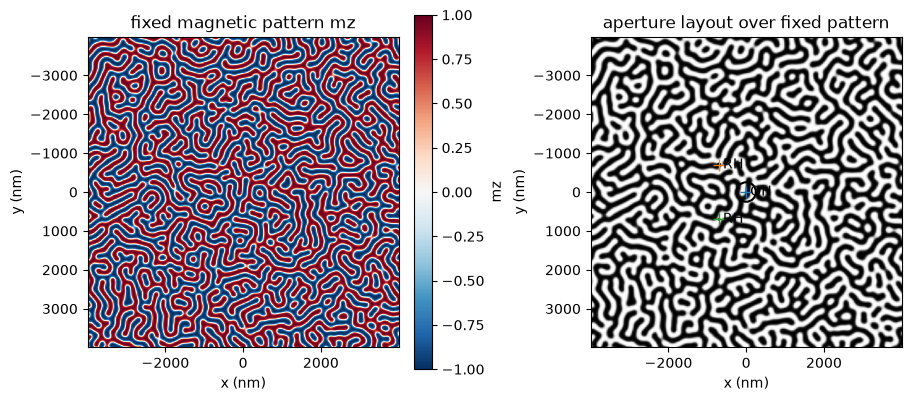

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
extent_nm = np.array([-sample_shape[2] / 2, sample_shape[2] / 2, sample_shape[1] / 2, -sample_shape[1] / 2]) * real_space_pixel_size * 1e9
im = axes[0].imshow(magnetic_pattern_2d, cmap="RdBu_r", vmin=-1, vmax=1, extent=extent_nm, interpolation="nearest")
axes[0].set_title("fixed magnetic pattern mz")
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("y (nm)")
fig.colorbar(im, ax=axes[0], label="mz")

# Draw the configured aperture centers and nominal bottom radii on top of the pattern.
axes[1].imshow(magnetic_pattern_2d, cmap="gray", extent=extent_nm, interpolation="nearest")
for typ, radius, center in zip(aperture_types, aperture_radii, aperture_centers):
    cy, cx = center
    circle = plt.Circle((cx * 1e9, cy * 1e9), radius * 1e9, fill=False, linewidth=1.5)
    axes[1].add_patch(circle)
    axes[1].plot(cx * 1e9, cy * 1e9, "+", markersize=8)
    axes[1].text(cx * 1e9, cy * 1e9, f" {typ}", va="center")
axes[1].set_title("aperture layout over fixed pattern")
axes[1].set_xlabel("x (nm)")
axes[1].set_ylabel("y (nm)")


## 3. Simulation Helpers

At each energy the notebook rebuilds the material optical constants and the dielectric tensor, because those are energy dependent. The magnetic pattern and aperture parameters are copied unchanged.

The XMCD exit-wave image is defined as:

```python
xmcd_log = log(exit_wave_CR / exit_wave_CL)
```

Its real part is the log-amplitude ratio. Its imaginary part is the phase difference, wrapped by the complex logarithm.


In [16]:
def frame_average(array):
    if isinstance(array, h5py.Dataset) and array.ndim == 3:
        # Read one frame at a time, including when analysing older saved runs.
        mean = np.zeros(array.shape[1:], dtype=np.result_type(array.dtype, np.float64))
        for index in range(array.shape[0]):
            mean += array[index]
        return mean / array.shape[0]
    array = np.asarray(array)
    return array.mean(axis=0) if array.ndim == 3 else array


def fth_reconstruct(hologram):
    """Reconstruct over the spatial axes without shifting a frame axis."""
    axes = (-2, -1)
    return np.fft.fftshift(
        np.fft.fft2(np.fft.fftshift(hologram, axes=axes), axes=axes),
        axes=axes,
    )


def symmetric_limits(data, percentile=99.0):
    vmax = np.nanpercentile(np.abs(data), percentile)
    return -float(vmax or 1.0), float(vmax or 1.0)


def continuous_phase(values):
    """Return a phase curve without artificial 2*pi branch-cut jumps."""
    phase = np.unwrap(np.angle(values))
    offset = 2 * np.pi * np.round(np.nanmedian(phase) / (2 * np.pi))
    return phase - offset


def continuous_complex_log_ratio(numerator, denominator, eps=1e-30):
    """Compute log(numerator / denominator) with an unwrapped imaginary part."""
    ratio = (np.asarray(numerator) + eps) / (np.asarray(denominator) + eps)
    return np.log(np.abs(ratio)) + 1j * continuous_phase(ratio)


def resample_nearest_to_shape(array, shape):
    """Nearest-neighbor resample a 2D mask/image to a requested shape."""
    array = np.asarray(array)
    if array.shape == tuple(shape):
        return array
    y_idx = np.rint(np.linspace(0, array.shape[0] - 1, shape[0])).astype(int)
    x_idx = np.rint(np.linspace(0, array.shape[1] - 1, shape[1])).astype(int)
    return array[np.ix_(y_idx, x_idx)]


def object_hole_crop_slices(shape, pixel_size, radius_factor=1.0):
    oh_index = aperture_types.index("OH")
    center_y_m, center_x_m = aperture_centers[oh_index]
    return crop_slices_around_position(shape, pixel_size, (center_y_m, center_x_m), aperture_radii[oh_index] * radius_factor)


def fth_object_image_crop_slices(shape, pixel_size, radius_factor=1.0):
    """Crop the FTH object image displaced by the selected RH-OH vector.

    In the exit wave the object hole is centered at its real-space OH position.
    In the FTH reconstruction, the object image appears in the cross-correlation
    term, shifted from the reconstruction origin by the reference-hole/object-hole
    separation. The sign selects which twin image to inspect.
    """
    oh_index = aperture_types.index("OH")
    oh_center = np.asarray(aperture_centers[oh_index], dtype=float)
    rh_center = np.asarray(aperture_centers[fth_reference_aperture_index], dtype=float)
    reconstruction_center = fth_reconstruction_shift_sign * (rh_center - oh_center)
    return crop_slices_around_position(
        shape,
        pixel_size,
        reconstruction_center,
        aperture_radii[oh_index] * radius_factor,
    )


def crop_slices_around_position(shape, pixel_size, center_m, radius_m):
    center_y_m, center_x_m = center_m
    cy = int(np.clip(round(shape[-2] / 2 + center_y_m / pixel_size), 0, shape[-2] - 1))
    cx = int(np.clip(round(shape[-1] / 2 + center_x_m / pixel_size), 0, shape[-1] - 1))
    half_width = max(4, int(np.ceil(radius_m / pixel_size)))
    y0 = max(0, cy - half_width)
    y1 = min(shape[-2], cy + half_width + 1)
    x0 = max(0, cx - half_width)
    x1 = min(shape[-1], cx + half_width + 1)
    return slice(y0, y1), slice(x0, x1)


sample_oh_slices = object_hole_crop_slices(sample_shape[1:], real_space_pixel_size, radius_factor=1.0)


def build_sample_and_aperture(xray_config):
    sample_config = sim.SampleConfig(
        recipe=recipe,
        sample_shape=sample_shape.copy(),
        real_space_pixel_size=real_space_pixel_size,
        xray_config=xray_config,
        sample_name=sample_name,
    )
    sample_config.setup()

    magnetization = pattern_generator.map_magnetization_to_3d(
        magnetic_pattern_x=np.zeros_like(magnetic_pattern_2d),
        magnetic_pattern_y=np.sqrt(np.clip(1 - np.abs(magnetic_pattern_2d) ** 2, 0, 1)),
        magnetic_pattern_z=magnetic_pattern_2d,
        nr_repeats=sample_config.sample_structure.sample_shape[0],
    )
    sample_config.assign_magnetic_pattern(magnetization)

    layer_thicknesses = sample_config.sample_structure.layer_thicknesses
    membrane_index = sample_config.sample_structure.layer_names.index("SiN")
    aperture_taper_depth = float(np.sum(layer_thicknesses[: max(0, membrane_index - 2)]))
    thickness_oh = float(np.sum(layer_thicknesses[:membrane_index]))

    aperture_config = sim.FrontApertureConfig(
        aperture_method="FTH_circular",
        aperture_shape=sample_config.sample_structure.sample_shape,
        real_space_pixel_size=real_space_pixel_size,
        aperture_thicknesses=layer_thicknesses,
        aperture_layer_names=sample_config.sample_structure.layer_names,
        use_roi=True,
        aperture_config={
            "apertures_type": aperture_types,
            "apertures_radius": aperture_radii,
            "apertures_center": aperture_centers,
            "apertures_sigma": aperture_sigmas,
            "apertures_angle": aperture_angles,
            "apertures_ellipticity": aperture_ellipticities,
            "apertures_roughness": aperture_roughnesses,
            "apertures_roughness_modes": aperture_roughness_modes,
            "apertures_seed": aperture_seeds,
            "apertures_top_radius_factor": aperture_top_radius_factors,
            "aperture_taper_depth": aperture_taper_depth,
            "thickness_OH": thickness_oh,
        },
    )
    aperture_config.setup()
    aperture_mask = aperture_config.return_aperture()
    sample_config.assign_aperture_mask(aperture_mask)

    if propagator_method == "Scalar":
        sample_config.sample_structure.calculate_final_scalar_refractive_index(
            pol=pols[0],
            use_aperture_roi=True,
            compact=True,
            lazy=scalar_refractive_index_lazy,
        )
    else:
        contrast_beam_direction = sim.light_beam.beam_direction_from_alpha(illumination_alpha_beam)
        if np.allclose(contrast_beam_direction, [0.0, 0.0, 1.0], atol=1e-14, rtol=0.0):
            contrast_beam_direction = None
        sample_config.sample_structure.calculate_final_dielectric_tensor(
            use_aperture_roi=True,
            compact=True if contrast_beam_direction is None else False,
            beam_direction=contrast_beam_direction,
        )
    return sample_config, aperture_config, aperture_mask


def membrane_split_index(structure):
    """Split the original, untilted layer stack immediately after its SiN layer."""
    if structure.layer_names.count("SiN") != 1:
        raise ValueError("Fixed mask illumination requires exactly one SiN layer.")
    split = structure.layer_names.index("SiN") + 1
    if split == len(structure.layer_names):
        raise ValueError("The recipe must contain film layers after SiN.")
    if len(structure.propagation_layer_thicknesses) != len(structure.layer_names):
        raise ValueError("Fixed mask illumination requires an untilted layer stack.")
    return split


def layer_stack_view(stack, start, stop):
    """Slice optical layers without materializing a dense mask volume."""
    if hasattr(stack, "base_index"):
        view = SimpleNamespace(
            shape=(stop - start, *stack.shape[1:]),
            base_index=stack.base_index[start:stop],
        )
        if hasattr(stack, "layer_patches"):
            view.layer_patches = lambda iz: stack.layer_patches(start + iz)
        else:
            view.patches = stack.patches[start:stop]
        return view
    if hasattr(stack, "base_diagonal"):
        return SimpleNamespace(
            shape=(stop - start, *stack.shape[1:]),
            base_diagonal=stack.base_diagonal[start:stop],
            ndim=5,
            patches=stack.patches[start:stop],
        )
    return stack[start:stop]


def stage_sample_config(sample_config, mask_stage=False):
    """Reuse the full-stack aperture geometry, selecting only this stage's optics."""
    structure = sample_config.sample_structure
    split = membrane_split_index(structure)
    start, stop = (0, split + 1) if mask_stage else (split, len(structure.layer_names))
    thicknesses = list(structure.propagation_layer_thicknesses[start:stop])
    if mask_stage:
        # The engine diffracts after every non-final slice. A zero-thickness
        # marker at the film entrance retains diffraction across the last SiN
        # slice without applying any film transmission or adding a vacuum gap.
        thicknesses[-1] = 0.0
    stage = SimpleNamespace(
        propagation_layer_thicknesses=thicknesses,
        aperture_support_regions=getattr(structure, "aperture_support_regions", None),
    )
    if propagator_method == "Scalar":
        def calculate_scalar(pol, **kwargs):
            structure.calculate_final_scalar_refractive_index(pol, **kwargs)
            stage.final_scalar_refractive_index = layer_stack_view(
                structure.final_scalar_refractive_index, start, stop
            )
        stage.calculate_final_scalar_refractive_index = calculate_scalar
    else:
        stage.final_dielectric_tensor = layer_stack_view(
            structure.final_dielectric_tensor, start, stop
        )
    return SimpleNamespace(sample_structure=stage, real_space_pixel_size=real_space_pixel_size)


def make_illumination(xray_config):
    illumination_config = sim.IlluminationConfig(
        XRayConfig=xray_config,
        shape=tuple(sample_shape[1:]),
        real_space_pixel_size=real_space_pixel_size,
        illumination_function="gaussian",
        illumination_config={
            "center": np.array(illumination_center),
            "distance": illumination_focus_distance,
            "fwhm": illumination_fwhm,
            "alpha_beam": illumination_alpha_beam,
        },
    )
    illumination_config.setup()
    return illumination_config


def propagation_options(do_propagate):
    return {
        "propagate": do_propagate,
        "jones_apply_zero_order_phase": jones_apply_zero_order_phase,
        "scalar_apply_zero_order_phase": jones_apply_zero_order_phase,
        "scalar_refractive_index_lazy": scalar_refractive_index_lazy,
        "propagation_padding_px": propagation_padding_px,
        "propagation_padding_mode": propagation_padding_mode,
        "propagation_absorber_width_px": propagation_absorber_width_px,
        "propagation_absorber_strength": propagation_absorber_strength,
        "propagation_absorber_profile": propagation_absorber_profile,
        "multislice_propagation_roi": multislice_propagation_roi,
        "multislice_propagation_roi_padding_px": multislice_propagation_roi_padding_px,
        "multislice_propagation_roi_merge_overlaps": multislice_propagation_roi_merge_overlaps,
    }


def prepare_fixed_mask_illumination():
    """Calculate once per sweep, retaining a complex field for each polarization."""
    if propagator_method not in ("Scalar", "Jones"):
        raise ValueError("Fixed mask illumination supports Scalar and Jones propagation.")
    xray = make_xray_config(mask_illumination_energy_eV)
    sample, _, _ = build_sample_and_aperture(xray)
    stage = stage_sample_config(sample, mask_stage=True)
    illumination = make_illumination(xray)
    fields = {}
    for pol in pols:
        illumination.update_polarization(pol)
        propagator = sim.SamplePropagatorConfig(
            SampleConfig=stage, IlluminationConfig=illumination,
            propagator_method=propagator_method,
            propagator_config={**propagation_options(True), "calculate_farfield": False},
        )
        propagator.setup()
        # Keep Jones components where available; never reduce them to an
        # amplitude/phase surrogate or normalize away mask absorption.
        fields[pol] = np.array(propagator.wavefront.exit_wave, copy=True)
        del propagator
    return fields


def simulate_one_energy(energy_eV, noise_seed_base=1000, fixed_mask_fields=None):
    xray_config = make_xray_config(energy_eV)
    detector_config = make_detector_config(noise_seed=noise_seed_base)
    projection_beam_params = (
        reference_xray_config.beam_params
        if FIX_DETECTOR_PROJECTION_ENERGY else xray_config.beam_params
    )
    detector_config.calc_realspace_resolution(projection_beam_params)
    sample_config, aperture_config, aperture_mask = build_sample_and_aperture(xray_config)

    illumination_config = make_illumination(xray_config)
    if FIX_MASK_ILLUMINATION and fixed_mask_fields is None:
        raise ValueError("Prepare fixed mask illumination before running the sweep.")
    propagation_sample = (
        stage_sample_config(sample_config) if FIX_MASK_ILLUMINATION else sample_config
    )

    hologram_config = sim.HologramConfig(
        sample_x=sample_config.sample_structure.x,
        sample_y=sample_config.sample_structure.y,
        detector_layout=detector_config.detector_layout,
    )


    for pol_index, pol in enumerate(pols):
        detector_config.detector_params["noise_seed"] = int(noise_seed_base) + pol_index
        illumination_config.update_polarization(pol)
        if FIX_MASK_ILLUMINATION:
            field = fixed_mask_fields[pol]
            illumination_config.illumination.illumination_jones = (
                sim.light_beam.scalar_to_jones(field, pol)
                if field.ndim == 2 else field.copy()
            )
        propagator_config = sim.SamplePropagatorConfig(
            SampleConfig=propagation_sample,
            IlluminationConfig=illumination_config,
            propagator_method=propagator_method,
            propagator_config=propagation_options(propagate),
        )
        propagator_config.setup()
        detector_config.assign_propagated_wavefront(propagator_config)
        # Use the selected energy for detector projection only.
        detector_config.detect_hologram(
            projection_beam_params=projection_beam_params,
        )

        hologram_config.add_exit_waves({pol: propagator_config.return_scalar_wavefield()})
        hologram_config.add_holograms({pol: detector_config.return_ideal_hologram()}, source="ideal")
        hologram_config.add_holograms({pol: detector_config.return_detected_hologram(store_no_beamstop=True)}, source="detected")
        hologram_config.add_holograms({pol: detector_config.return_detected_hologram_without_beamstop()}, source="detected_no_beamstop")
        del propagator_config

    hologram_config.compute_differences(positive=pols[0], negative=pols[1])
    hologram_config.compute_sums(left=pols[0], right=pols[1])
    # Keep native images; their physical pixel size follows the projection energy.
    fth_hologram_scale = 1.0
    # Reconstruct frame by frame during HDF5 writing, after releasing the sample.
    eps = 1e-30
    xmcd_ratio = (hologram_config.exit_waves[pols[0]] + eps) / (hologram_config.exit_waves[pols[1]] + eps)
    xmcd_log = np.log(xmcd_ratio)
    native_reconstruction_pixel_size = detector_config.detector_layout.real_space_resolution
    reconstruction_pixel_size = native_reconstruction_pixel_size * fth_hologram_scale
    supportmask = aperture_config.create_supportmask(
        output_shape=detector_config.detector_layout.detector_shape,
        output_pixel_size=reconstruction_pixel_size,
    )
    recon_oh_slices = fth_object_image_crop_slices(detector_shape, reconstruction_pixel_size, radius_factor=1.0)
    oh_index = aperture_types.index("OH")
    fth_shift_m = fth_reconstruction_shift_sign * (
        np.asarray(aperture_centers[fth_reference_aperture_index], dtype=float)
        - np.asarray(aperture_centers[oh_index], dtype=float)
    )

    total_ideal_intensity = float(np.sum(hologram_config.ideal_holograms["sum"]))
    total_detected_counts = float(np.sum(hologram_config.detected_holograms["sum"]))

    # These objects own large sample meshes and propagation work arrays. None of
    # the analysis cells below uses them, so do not retain them across energies.
    hologram_config.sample_x = None
    hologram_config.sample_y = None
    hologram_config.detector_layout = None

    return {
        "energy_eV": float(energy_eV),
        "supportmask": supportmask,
        "beamstop_mask": np.asarray(detector_config.detector_layout.beamstop).copy(),
        "holograms": hologram_config,
        "xmcd_ratio": xmcd_ratio,
        "xmcd_log": xmcd_log,
        "sample_oh_slices": sample_oh_slices,
        "recon_oh_slices": recon_oh_slices,
        "fth_hologram_scale": fth_hologram_scale,
        "reconstruction_pixel_size": reconstruction_pixel_size,
        "fth_reconstruction_shift_m": fth_shift_m,
        "total_ideal_intensity": total_ideal_intensity,
        "total_detected_counts": total_detected_counts,
    }


## 4. Preview The Fixed Aperture Mask

This cell uses the reference energy only to build the material stack. The aperture geometry is then reused at every energy.


8739

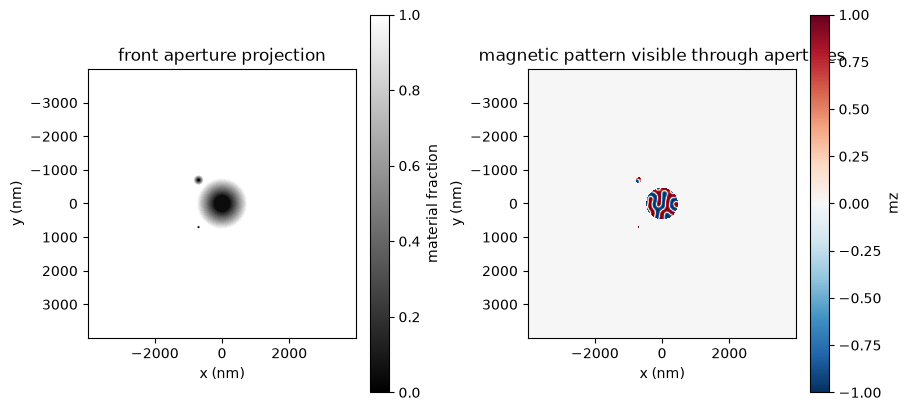

In [17]:
get_ipython().run_line_magic("matplotlib", "inline")
preview_sample, preview_aperture, preview_aperture_mask = build_sample_and_aperture(reference_xray_config)
projection = np.mean(preview_aperture_mask, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
im0 = axes[0].imshow(projection, cmap="gray", vmin=0, vmax=1, extent=extent_nm, interpolation="nearest")
axes[0].set_title("front aperture projection")
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("y (nm)")
fig.colorbar(im0, ax=axes[0], label="material fraction")

masked_pattern = magnetic_pattern_2d * (projection < 0.5)
im1 = axes[1].imshow(masked_pattern, cmap="RdBu_r", vmin=-1, vmax=1, extent=extent_nm, interpolation="nearest")
axes[1].set_title("magnetic pattern visible through apertures")
axes[1].set_xlabel("x (nm)")
axes[1].set_ylabel("y (nm)")
fig.colorbar(im1, ax=axes[1], label="mz")

# The preview needs only its 2D images; release the sample before the sweep.
del preview_sample, preview_aperture, preview_aperture_mask
gc.collect()


## 5. Run The Energy Sweep

Each completed energy is written immediately to HDF5 and removed from RAM. Reconstructions are computed and saved one frame at a time, and analysis averages saved frames incrementally. The `energy_results` list contains lightweight HDF5-backed views, so later analysis cells load only the arrays they currently use.

The swept energy controls the sample refractive indices and transmission (including propagation within the sample). Choose detector behavior with `FIX_DETECTOR_PROJECTION_ENERGY` in the configuration cell:

- `True` (default): use `reference_energy_eV` for all detector projections, keeping detector and FTH images at a common spatial scale.
- `False`: use each swept energy for detector projection, allowing the physical image scale to vary with energy.

Neither mode resizes the resulting images afterward. Reconstruction pixel sizes and support masks follow the selected projection energy. The film response (and mask response unless fixed illumination is enabled) uses the swept energy in both modes, and material contrast can still change image appearance.


In [18]:
def _create_sweep_file(base_path):
    """Create a new output exclusively, preserving all previous runs."""
    base_path = Path(base_path)
    base_path.parent.mkdir(parents=True, exist_ok=True)
    run_number = 0
    while True:
        path = base_path if run_number == 0 else base_path.with_name(
            f"{base_path.stem}_{run_number:03d}{base_path.suffix}"
        )
        try:
            return path, h5py.File(path, "x")
        except FileExistsError:
            run_number += 1


def _write_array(group, name, value):
    """Write an array without a full-size precision-conversion copy."""
    group.create_dataset(name, data=np.asarray(value), compression="lzf", shuffle=True)


def _write_reconstruction(group, name, frames):
    """Preserve every frame while bounding FFT work memory to one 2D image."""
    if frames.ndim == 2:
        _write_array(group, name, fth_reconstruct(frames))
        return
    dataset = group.create_dataset(
        name, shape=frames.shape, dtype=np.complex128,
        chunks=(1, *frames.shape[-2:]), compression="lzf", shuffle=True,
    )
    for index in range(frames.shape[0]):
        dataset[index] = fth_reconstruct(frames[index])


def _write_energy_result(group, result):
    for name in ("energy_eV", "fth_hologram_scale", "reconstruction_pixel_size",
                 "total_ideal_intensity", "total_detected_counts"):
        group.attrs[name] = result[name]
    group.attrs["fth_reconstruction_shift_m"] = result["fth_reconstruction_shift_m"]
    for name in ("sample_oh_slices", "recon_oh_slices"):
        sy, sx = result[name]
        group.attrs[name] = [sy.start, sy.stop, sx.start, sx.stop]
    for name in ("supportmask", "beamstop_mask", "xmcd_ratio", "xmcd_log"):
        _write_array(group, name, result[name])
    h = result["holograms"]
    hg = group.create_group("holograms")
    stores = {"ideal": h.ideal_holograms, "detected": h.detected_holograms,
              "detected_no_beamstop": h.detected_holograms_no_beamstop,
              "exit_waves": h.exit_waves}
    for store_name, store in stores.items():
        sg = hg.create_group(store_name)
        for key, value in store.items():
            _write_array(sg, key, value)
    rg = hg.create_group("reconstructions")
    for source in ("ideal", "detected", "detected_no_beamstop"):
        sg = rg.create_group(source)
        for key, value in stores[source].items():
            _write_reconstruction(sg, key, value)


def _slice_pair(values):
    return slice(int(values[0]), int(values[1])), slice(int(values[2]), int(values[3]))


def _energy_result_view(group):
    h = group["holograms"]
    holograms = SimpleNamespace(
        ideal_holograms=h["ideal"], detected_holograms=h["detected"],
        detected_holograms_no_beamstop=h["detected_no_beamstop"],
        exit_waves=h["exit_waves"],
        reconstructions={name: h["reconstructions"][name] for name in h["reconstructions"]},
    )
    return {
        "energy_eV": float(group.attrs["energy_eV"]), "holograms": holograms,
        "supportmask": group["supportmask"], "beamstop_mask": group["beamstop_mask"],
        "xmcd_ratio": group["xmcd_ratio"], "xmcd_log": group["xmcd_log"],
        "sample_oh_slices": _slice_pair(group.attrs["sample_oh_slices"]),
        "recon_oh_slices": _slice_pair(group.attrs["recon_oh_slices"]),
        "fth_hologram_scale": float(group.attrs["fth_hologram_scale"]),
        "reconstruction_pixel_size": float(group.attrs["reconstruction_pixel_size"]),
        "fth_reconstruction_shift_m": np.asarray(group.attrs["fth_reconstruction_shift_m"]),
        "total_ideal_intensity": float(group.attrs["total_ideal_intensity"]),
        "total_detected_counts": float(group.attrs["total_detected_counts"]),
    }


if "_energy_results_file" in globals() and _energy_results_file:
    _energy_results_file.close()
_energy_results_file = None
energy_results = []

if RUN_ENERGY_SWEEP:
    fixed_mask_fields = None
    if FIX_MASK_ILLUMINATION:
        print(f"Propagating mask + SiN once at {mask_illumination_energy_eV:.2f} eV")
        fixed_mask_fields = prepare_fixed_mask_illumination()
        gc.collect()  # Release stage closures and their full sample before the film run.
    HDF5_OUTPUT_PATH, output_file = _create_sweep_file(HDF5_BASE_PATH)
    print(f"Saving this run to {HDF5_OUTPUT_PATH}")
    with output_file:
        output_file.attrs["fix_mask_illumination"] = FIX_MASK_ILLUMINATION
        output_file.attrs["propagate"] = propagate
        output_file.attrs["propagator_method"] = propagator_method
        if FIX_MASK_ILLUMINATION:
            output_file.attrs["mask_illumination_energy_eV"] = float(mask_illumination_energy_eV)
            fields_group = output_file.create_group("fixed_mask_illumination")
            fields_group.attrs["plane"] = "after SiN / before film"
            fields_group.attrs["real_space_pixel_size_m"] = float(real_space_pixel_size)
            for pol, field in fixed_mask_fields.items():
                _write_array(fields_group, pol, field)
        output_file.attrs["fix_detector_projection_energy"] = FIX_DETECTOR_PROJECTION_ENERGY
        output_file.attrs["reference_energy_eV"] = float(reference_energy_eV)
        output_file.create_dataset(
            "detector_projection_energies_eV",
            data=(np.full_like(energy_values_eV, reference_energy_eV, dtype=float)
                  if FIX_DETECTOR_PROJECTION_ENERGY else energy_values_eV),
        )
        output_file.create_dataset("energies", data=energy_values_eV)
        results_group = output_file.create_group("results")
        for i, energy in enumerate(energy_values_eV):
            print(f"[{i + 1:02d}/{len(energy_values_eV)}] Simulating {energy:.2f} eV")
            result = simulate_one_energy(energy, noise_seed_base=1000 + 10 * i,
                                         fixed_mask_fields=fixed_mask_fields)
            gc.collect()  # Release sample/stage cycles before reconstruction.
            _write_energy_result(results_group.create_group(f"{i:05d}"), result)
            output_file.flush()
            del result
            gc.collect()
    print(f"Done. Streamed results to {HDF5_OUTPUT_PATH}")
else:
    print(f"Sweep disabled; loading existing results from {HDF5_OUTPUT_PATH}")

if HDF5_OUTPUT_PATH.exists():
    _energy_results_file = h5py.File(HDF5_OUTPUT_PATH, "r")
    if "results" in _energy_results_file:
        energy_results = [
            _energy_result_view(_energy_results_file["results"][key])
            for key in sorted(_energy_results_file["results"])
        ]
    print(f"Loaded {len(energy_results)} disk-backed energy results.")


Propagating mask + SiN once at 780.00 eV
Saving this run to /home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_013.h5
[01/5] Simulating 779.50 eV
[02/5] Simulating 780.00 eV
[03/5] Simulating 784.00 eV
[04/5] Simulating 787.00 eV
[05/5] Simulating 788.30 eV
Done. Streamed results to /home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_013.h5
Loaded 5 disk-backed energy results.


## 6. XMCD Exit-Wave Log Ratio

The complex image below is evaluated inside the object-hole ROI:

- `real(log(CR/CL)) = log(abs(CR/CL))`: signed absorption XMCD amplitude;
- `imag(log(CR/CL))`: signed phase XMCD in radians;
- `abs(CR/CL)`: raw helicity-ratio modulus, useful for intuition;
- `angle(CR/CL)`: raw helicity-ratio phase before taking the complex log.

Each column uses one fixed colorbar range across all displayed energies, so apparent contrast changes are not caused by automatic rescaling.


### XMCD Amplitude And Phase Definitions

Following the ratio-contrast convention, the complex XMCD signal is defined as

```python
XMCD = log(exit_wave_CR / exit_wave_CL)
```

The two physically useful signed quantities are then

- $A_\mathrm{XMCD} = \log{|\phi_\mathrm{CR}/\phi_\mathrm{CL}|} = \mathrm{Re}[\log(\phi_\mathrm{CR}/\phi_\mathrm{CL})]$: absorption XMCD amplitude;
- $\Theta_\mathrm{XMCD} = \arg(\phi_\mathrm{CR}/\phi_\mathrm{CL}) = \mathrm{Im}[\log(\phi_\mathrm{CR}/\phi_\mathrm{CL})]$: phase XMCD.

Both are signed. Opposite magnetic domains should therefore appear with opposite signs in $A_\mathrm{XMCD}$ and $\Theta_\mathrm{XMCD}$. The quantity `abs(log(CR/CL))` is not used as the XMCD amplitude because it removes that sign.


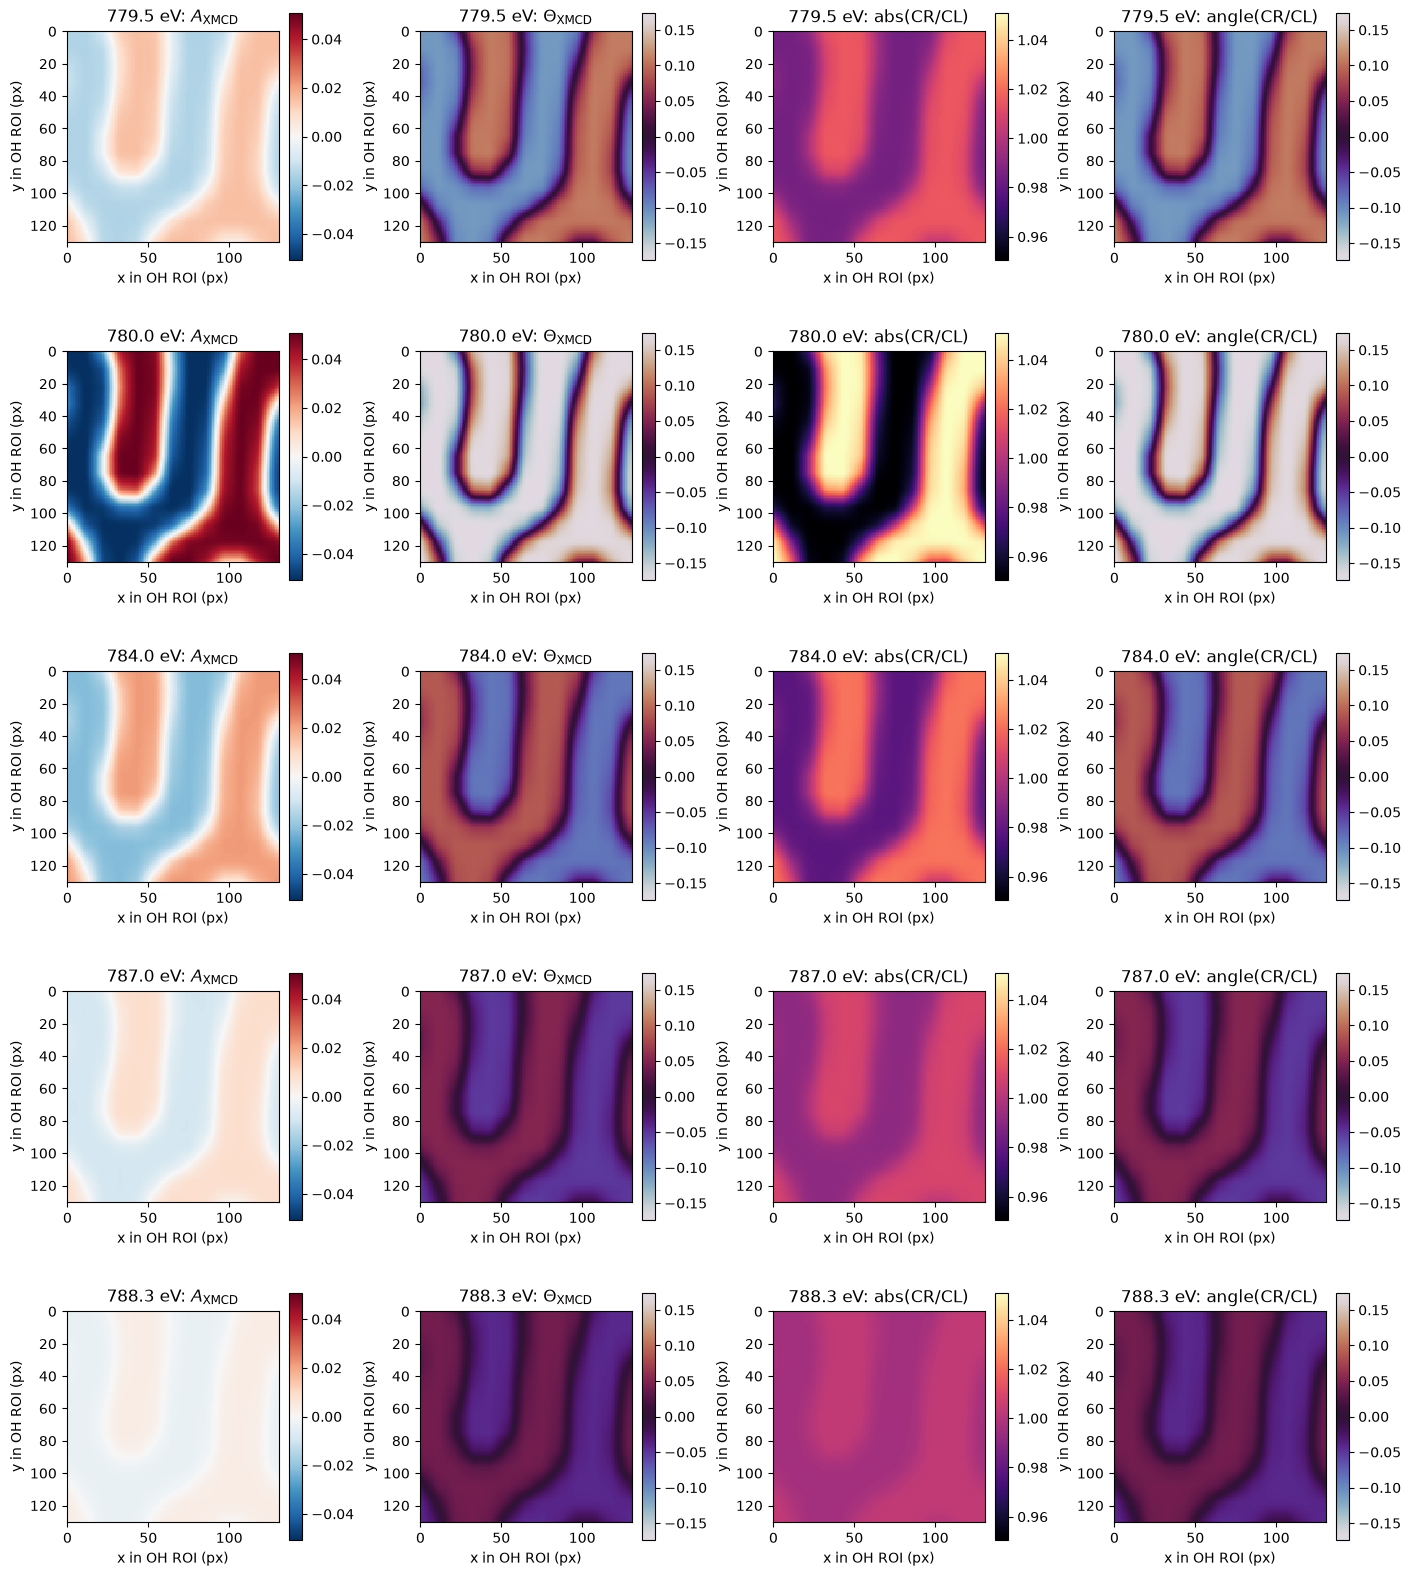

In [19]:
if energy_results:
    selected_indices = sorted(set(np.arange(0,len(energy_results),len(energy_results)//4)))
    rows = []
    for idx in selected_indices:
        result = energy_results[idx]
        crop = result["sample_oh_slices"]
        data = frame_average(result["xmcd_log"])[crop]
        ratio = frame_average(result["xmcd_ratio"])[crop]
        rows.append(
            {
                "energy_eV": result["energy_eV"],
                "panels": [
                    (np.real(data), "$A_{\\mathrm{XMCD}}$", "RdBu_r", True),
                    (np.imag(data), "$\\Theta_{\\mathrm{XMCD}}$", "twilight", True),
                    (np.abs(ratio), "abs(CR/CL)", "magma", False),
                    (np.angle(ratio), "angle(CR/CL)", "twilight", True),
                ],
            }
        )

    column_limits = []
    for col in range(4):
        images = [row["panels"][col][0] for row in rows]
        symmetric = rows[0]["panels"][col][3]
        stacked = np.concatenate([np.ravel(image) for image in images])
        if symmetric:
            vmax = np.nanpercentile(np.abs(stacked), 99)
            column_limits.append((-float(vmax or 1.0), float(vmax or 1.0)))
        else:
            column_limits.append(tuple(np.nanpercentile(stacked, [1, 99])))

    fig, axes = plt.subplots(len(rows), 4, figsize=(14, 3.2 * len(rows)), squeeze=False)

    for row_index, row in enumerate(rows):
        panels = row["panels"]
        for col, (image, title, cmap, symmetric) in enumerate(panels):
            ax = axes[row_index, col]
            vmin, vmax = column_limits[col]
            im = ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
            ax.set_title(f"{row['energy_eV']:.1f} eV: {title}")
            ax.set_xlabel("x in OH ROI (px)")
            ax.set_ylabel("y in OH ROI (px)")
            fig.colorbar(im, ax=ax, shrink=0.8)
else:
    print("No sweep results available yet.")


## 7. Holograms Across The Edge

The detected `CR`, `CL`, and `CR - CL` holograms are shown for a few representative energies. The individual helicity holograms are plotted on a logarithmic scale because the central intensity dominates the dynamic range.

Colorbar limits are fixed per column across all displayed energies.


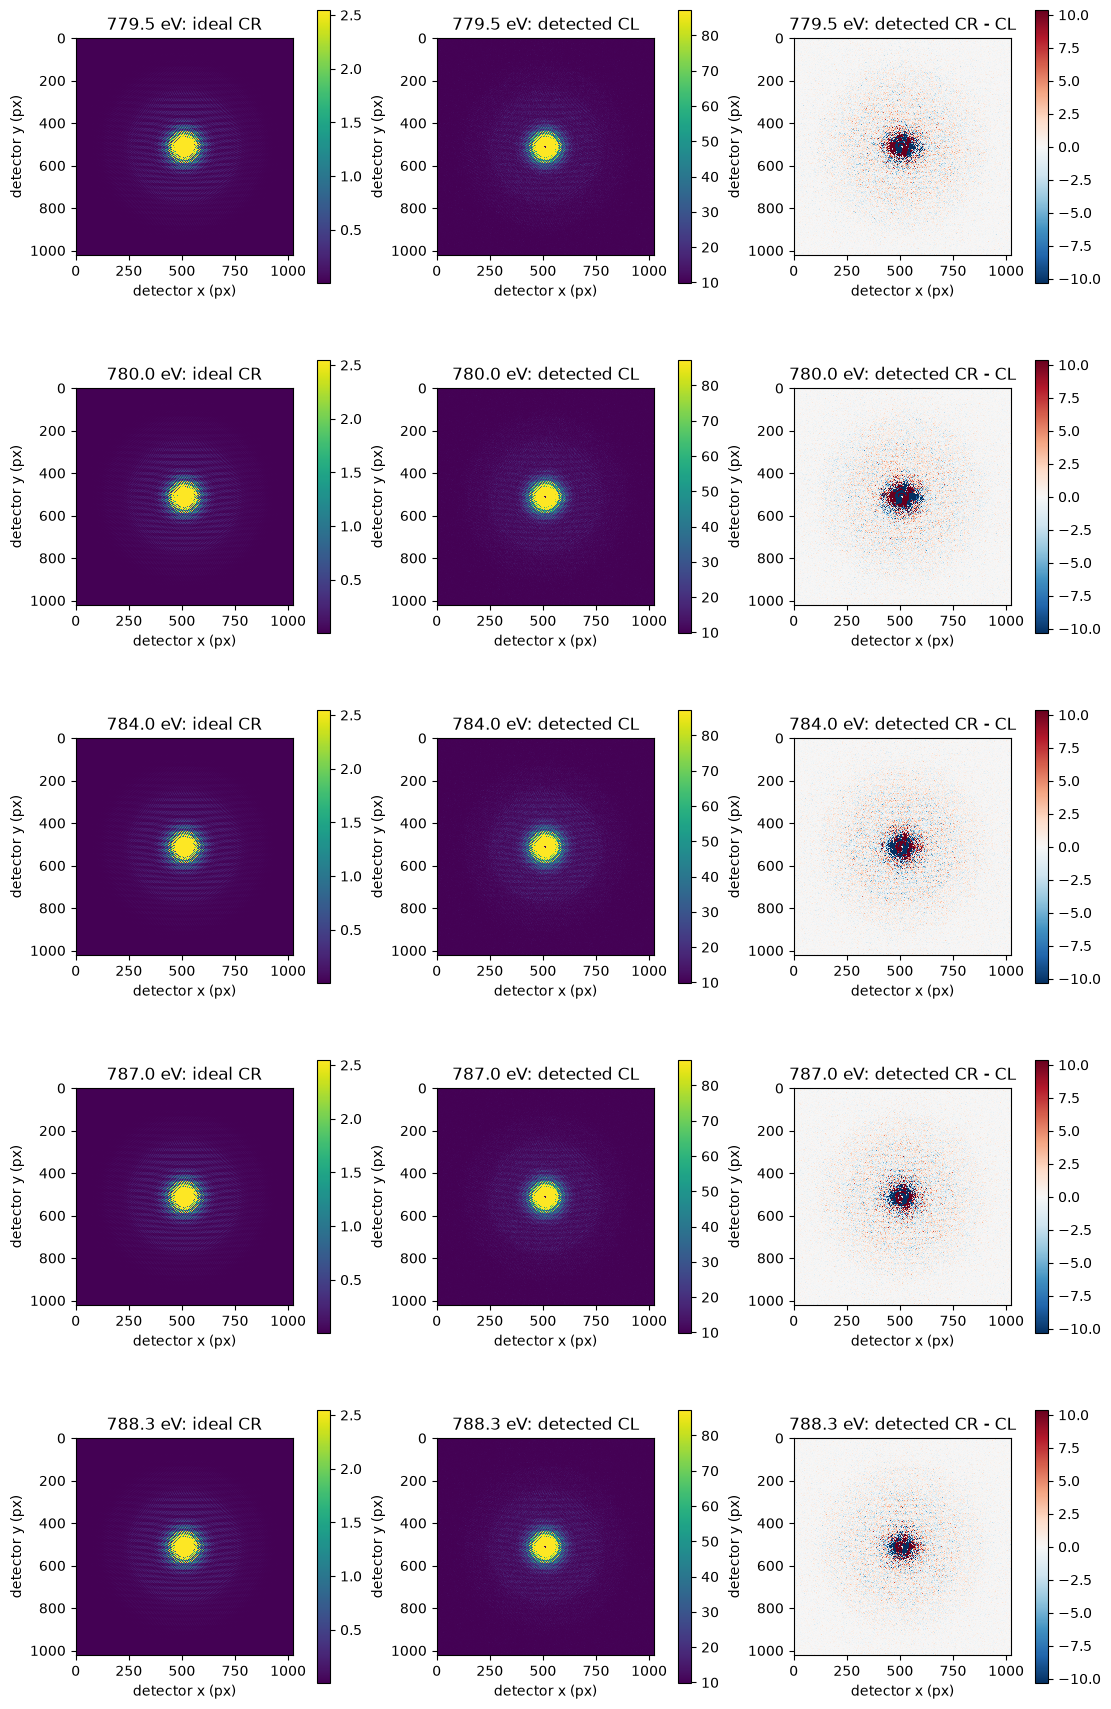

In [20]:
if energy_results:
    selected_indices = sorted(set(np.arange(0,len(energy_results),len(energy_results)//4)))
    rows = []
    for idx in selected_indices:
        result = energy_results[idx]
        h = result["holograms"]
        cr = frame_average(h.ideal_holograms[pols[0]])
        cl = frame_average(h.detected_holograms[pols[1]])
        diff = frame_average(h.detected_holograms["diff"])
        rows.append(
            {
                "energy_eV": result["energy_eV"],
                "panels": [
                    ((np.maximum(cr, 1e-5)), "ideal %s"%pols[0], "viridis", False),
                    ((np.maximum(cl, 1e-5)), "detected %s"%pols[1], "viridis", False),
                    (diff, "detected %s - %s"%(pols[0],pols[1]), "RdBu_r", True),
                ],
            }
        )

    column_limits = []
    for col in range(3):
        images = [row["panels"][col][0] for row in rows]
        symmetric = rows[0]["panels"][col][3]
        stacked = np.concatenate([np.ravel(image) for image in images])
        if symmetric:
            vmax = np.nanpercentile(np.abs(stacked), 99)
            column_limits.append((-float(vmax or 1.0), float(vmax or 1.0)))
        else:
            column_limits.append(tuple(np.nanpercentile(stacked, [1, 99])))

    fig, axes = plt.subplots(len(rows), 3, figsize=(11, 3.5 * len(rows)), squeeze=False)

    for row_index, row in enumerate(rows):
        panels = row["panels"]
        for col, (image, title, cmap, symmetric) in enumerate(panels):
            ax = axes[row_index, col]
            vmin, vmax = column_limits[col]
            im = ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
            ax.set_title(f"{row['energy_eV']:.1f} eV: {title}")
            ax.set_xlabel("detector x (px)")
            ax.set_ylabel("detector y (px)")
            fig.colorbar(im, ax=ax, shrink=0.8)
else:
    print("No sweep results available yet.")


## 8. FTH Reconstructions Cropped To The Shifted Object Image

The object-hole crop used for the exit wave is centered on the real-space OH. The FTH reconstruction is different: the reconstructed object appears in the OH/RH cross-correlation term, shifted away from the reconstruction origin by the reference-hole/object-hole separation vector.

This notebook uses `fth_reference_aperture_index` to pick the RH and crops around `fth_reconstruction_shift_sign * (RH_center - OH_center)`. Flip `fth_reconstruction_shift_sign` if you want the conjugate/twin object image on the opposite side.

The displayed crop is intentionally tight: it uses the physical OH radius without the larger visualization padding used in some broader overview notebooks. Amplitude colorbar limits are fixed per column across all displayed energies. Phase is always shown on `[-pi, pi]`.


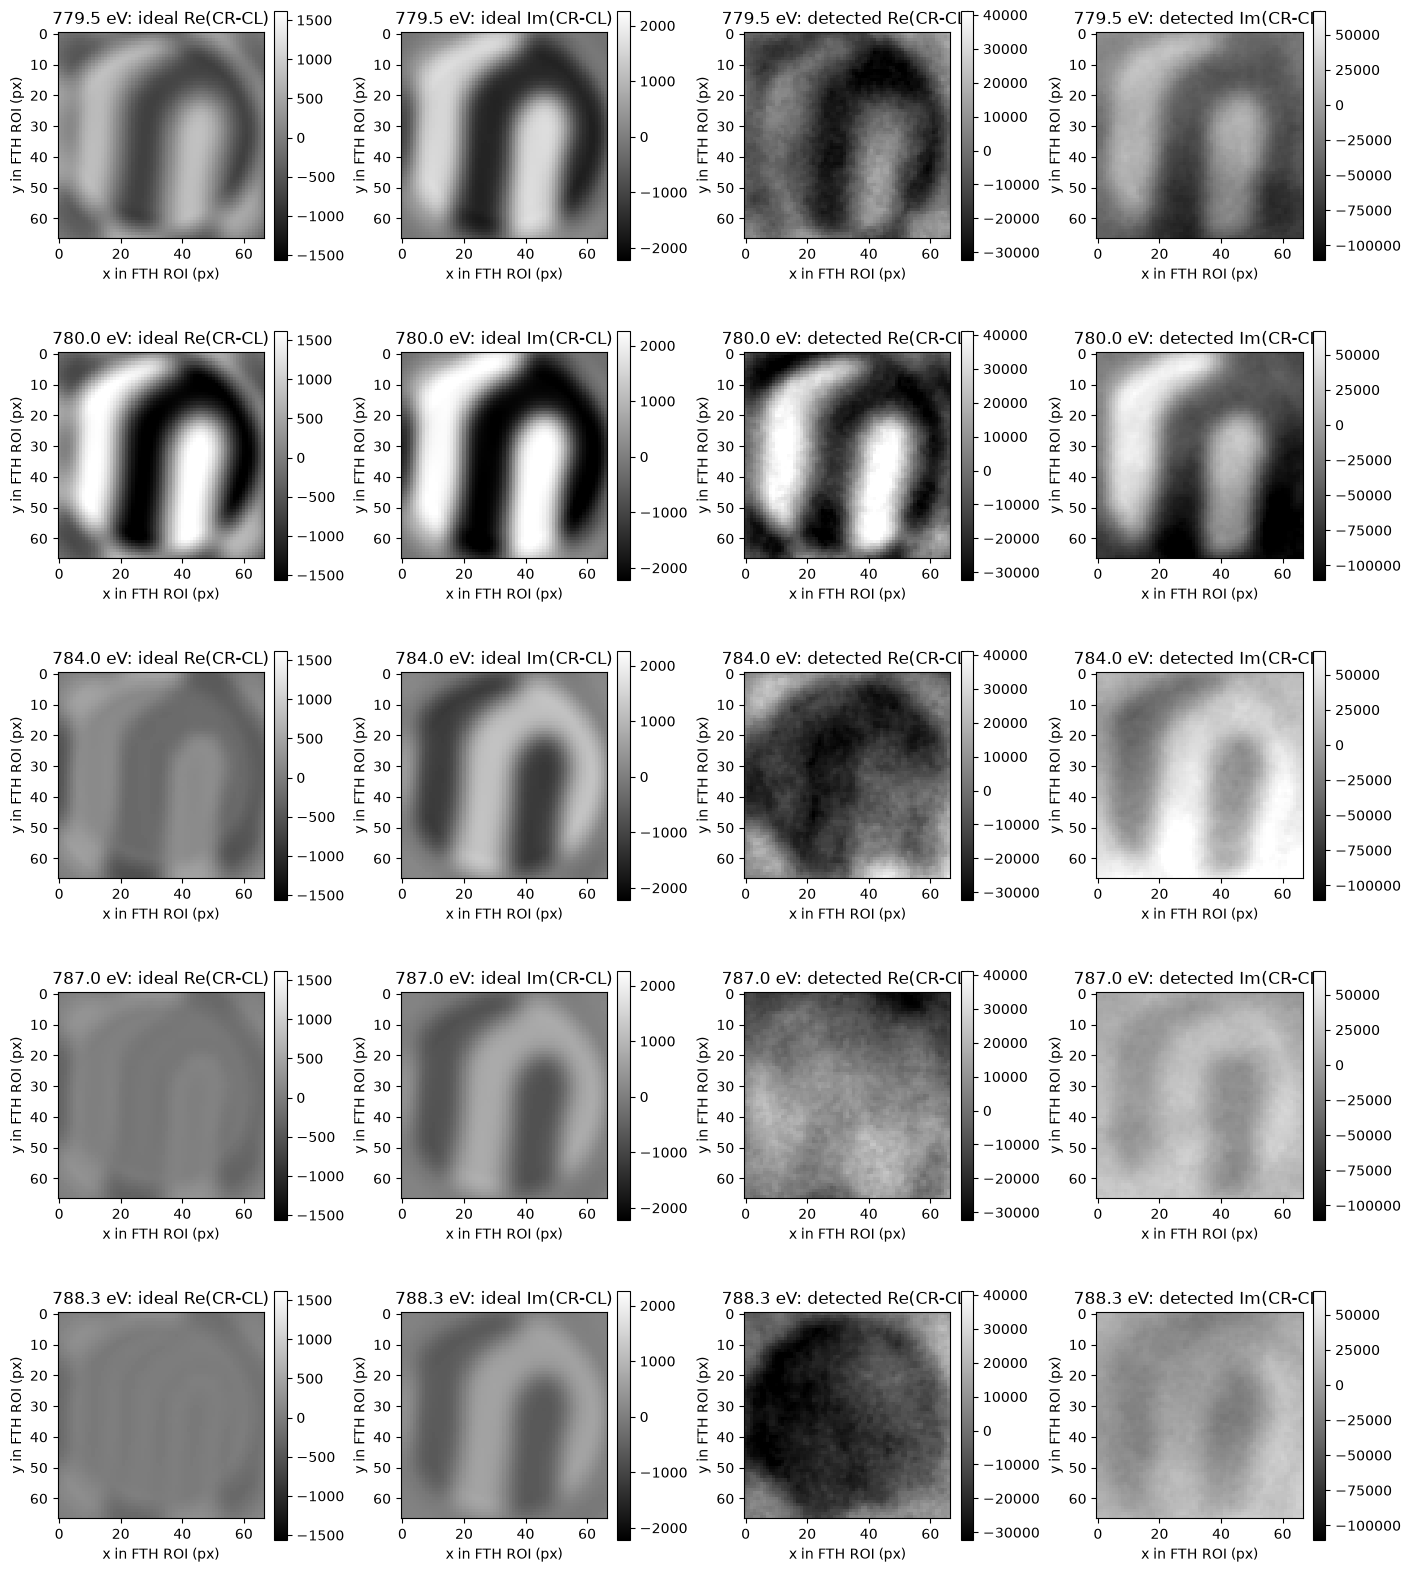

In [49]:
if energy_results:
    selected_indices = sorted(set(np.arange(0,len(energy_results),len(energy_results)//4)))
    rows = []
    for idx in selected_indices:
        result = energy_results[idx]
        h = result["holograms"]
        crop = result["recon_oh_slices"]
        ideal = frame_average(h.reconstructions["ideal"]["diff"])[crop]
        detected = frame_average(h.reconstructions["detected"]["diff"])[crop]
        rows.append(
            {
                "energy_eV": result["energy_eV"],
                "panels": [
                    (np.real(ideal), "ideal Re(CR-CL)", "gray", False),
                    (np.imag(ideal), "ideal Im(CR-CL)", "gray", False),
                    (np.real(detected), "detected Re(CR-CL)", "gray", False),
                    (np.imag(detected), "detected Im(CR-CL)", "gray", False),
                ],
            }
        )

    column_limits = []
    for col in range(4):
        images = [row["panels"][col][0] for row in rows]
        symmetric = rows[0]["panels"][col][3]
        if symmetric:
            column_limits.append((-np.pi, np.pi))
        else:
            stacked = np.concatenate([np.ravel(image) for image in images])
            column_limits.append(tuple(np.nanpercentile(stacked, [1, 99])))

    fig, axes = plt.subplots(len(rows), 4, figsize=(14, 3.2 * len(rows)), squeeze=False)

    for row_index, row in enumerate(rows):
        panels = row["panels"]
        for col, (image, title, cmap, symmetric) in enumerate(panels):
            ax = axes[row_index, col]
            vmin, vmax = column_limits[col]
            im = ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
            ax.set_title(f"{row['energy_eV']:.1f} eV: {title}")
            ax.set_xlabel("x in FTH ROI (px)")
            ax.set_ylabel("y in FTH ROI (px)")
            fig.colorbar(im, ax=ax, shrink=0.8)
else:
    print("No sweep results available yet.")


## 9. Ideal FTH XMCD Images In The Shifted Object Crop

The panels below show the XMCD ratio extracted directly from the ideal FTH reconstructions:

```python
FTH_XMCD = log(FTH_CR / FTH_CL)
```

The plotted maps are $A_\mathrm{XMCD} = \mathrm{Re}[\log(FTH_CR/FTH_CL)]$ and $\Theta_\mathrm{XMCD} = \mathrm{Im}[\log(FTH_CR/FTH_CL)]$. The crop is the shifted FTH object image crop, centered at `fth_reconstruction_shift_sign * (RH_center - OH_center)`, not at the reconstruction origin.

Colorbar limits are fixed per column across all displayed energies.


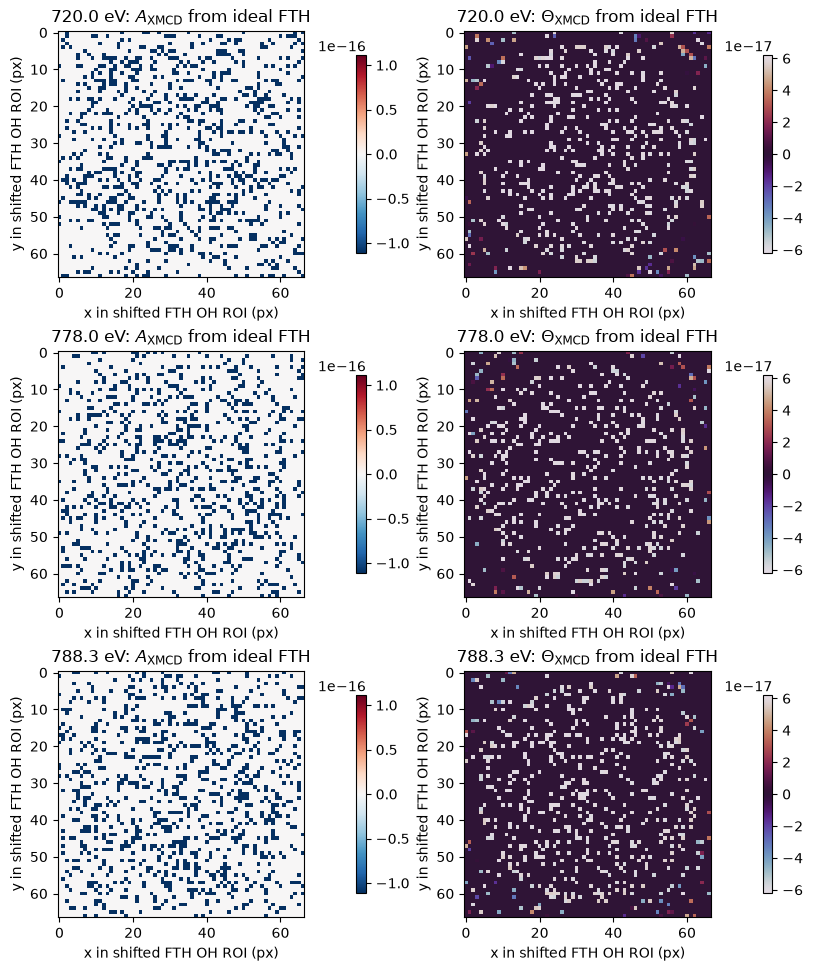

In [45]:
if energy_results:
    selected_indices = sorted(set(np.arange(0,len(energy_results),8)))
    rows = []
    eps = 1e-30
    for idx in selected_indices:
        result = energy_results[idx]
        h = result["holograms"]
        crop = result["recon_oh_slices"]
        fth_cr = frame_average(h.reconstructions["ideal"][pols[0]])[crop]
        fth_cl = frame_average(h.reconstructions["ideal"][pols[1]])[crop]
        fth_ratio = (fth_cr + eps) / (fth_cl + eps)
        fth_xmcd_log = np.log(fth_ratio)
        rows.append(
            {
                "energy_eV": result["energy_eV"],
                "panels": [
                    (np.real(fth_xmcd_log), "$A_{\\mathrm{XMCD}}$ from ideal FTH", "RdBu_r", True),
                    (np.imag(fth_xmcd_log), "$\\Theta_{\\mathrm{XMCD}}$ from ideal FTH", "twilight", True),
                ],
            }
        )

    column_limits = []
    for col in range(2):
        images = [row["panels"][col][0] for row in rows]
        symmetric = rows[0]["panels"][col][3]
        stacked = np.concatenate([np.ravel(image) for image in images])
        if symmetric:
            vmax = np.nanpercentile(np.abs(stacked), 99)
            column_limits.append((-float(vmax or 1.0), float(vmax or 1.0)))
        else:
            column_limits.append(tuple(np.nanpercentile(stacked, [1, 99])))

    fig, axes = plt.subplots(len(rows), 2, figsize=(8, 3.2 * len(rows)), squeeze=False)

    for row_index, row in enumerate(rows):
        panels = row["panels"]
        for col, (image, title, cmap, symmetric) in enumerate(panels):
            ax = axes[row_index, col]
            vmin, vmax = column_limits[col]
            im = ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
            ax.set_title(f"{row['energy_eV']:.1f} eV: {title}")
            ax.set_xlabel("x in shifted FTH OH ROI (px)")
            ax.set_ylabel("y in shifted FTH OH ROI (px)")
            fig.colorbar(im, ax=ax, shrink=0.8)
else:
    print("No sweep results available yet.")


## 10. Total Intensity Versus Energy

The edge scan should change the transmitted/scattered intensity because the optical constants vary strongly across the Cobalt L3 and L2 edges. The detected curve includes the beamstop, detector response, and noise; the ideal curve is the noiseless `CR + CL` detector intensity before detector noise.



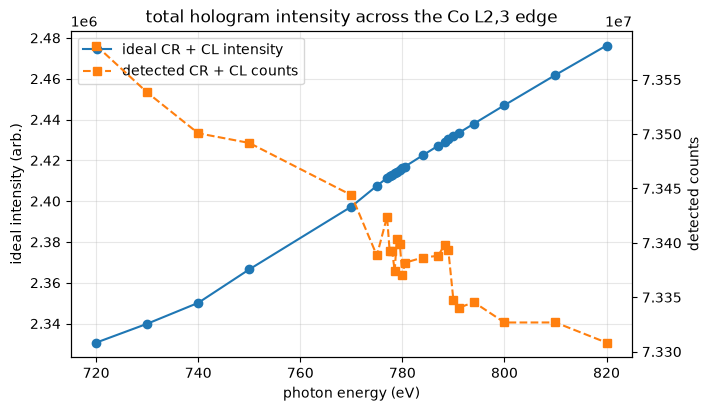

In [46]:
if energy_results:
    energies = np.array([result["energy_eV"] for result in energy_results])
    ideal_intensity = np.array([result["total_ideal_intensity"] for result in energy_results])
    detected_counts = np.array([result["total_detected_counts"] for result in energy_results])

    fig, ax1 = plt.subplots(figsize=(7, 4))
    ax1.plot(energies, ideal_intensity, "o-", label="ideal CR + CL intensity")
    ax1.set_xlabel("photon energy (eV)")
    ax1.set_ylabel("ideal intensity (arb.)")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(energies, detected_counts, "s--", color="tab:orange", label="detected CR + CL counts")
    ax2.set_ylabel("detected counts")

    lines = ax1.get_lines() + ax2.get_lines()
    ax1.legend(lines, [line.get_label() for line in lines], loc="best")
    ax1.set_title("total hologram intensity across the Co L2,3 edge")
else:
    print("No sweep results available yet.")

## 11. XMCD Signal Versus Energy

The image panels show where the XMCD contrast lives. This cell turns that into a spectrum by averaging the complex XMCD signal inside magnetic domains:

```python
XMCD = log(exit_wave_CR / exit_wave_CL)
```

Pixels with `mz > xmcd_domain_threshold` define the positive domain; pixels with `mz < -xmcd_domain_threshold` define the negative domain. Pixels near domain walls are skipped so the average is not dominated by smoothed boundaries.

The plotted complex averages are computed from the domain-averaged complex ratio `exit_wave_CR / exit_wave_CL`. This avoids averaging already-logged pixels before taking another logarithm.

For a pure circular XMCD contribution, reversing `mz` swaps the CR and CL effective indices. That means `log(CR/CL)` changes sign between up and down domains. The signed amplitude contrast is therefore `real(log(CR/CL)) = log(abs(CR/CL))`, not `abs(log(CR/CL))`; the latter discards the sign and can make opposite domains look artificially identical.

- positive-domain `log(mean(CR/CL))`;
- negative-domain `log(mean(CR/CL))`;
- domain contrast, `log(mean(CR/CL)_positive / mean(CR/CL)_negative)`.

The positive/negative domain means are plotted on the left y-axis. The logarithmic domain contrast is plotted on a separate right y-axis, because it can naturally have a different scale.

In the first row, the y values are `$A_\mathrm{XMCD}$`: the signed log-amplitude ratio, and `$\Theta_\mathrm{XMCD}$`: the signed phase of the same helicity ratio, measured directly from the exit waves.

For readability, the exit-wave and ideal-FTH XMCD rows are plotted with vertical offsets: the positive/negative domain means are placed in the upper band, while the green positive-versus-negative XMCD contrast is placed in the lower band. The translucent green fill shows the area between each contrast curve and its own zero baseline.

The second row repeats the ratio analysis on the ideal FTH reconstructions, using `log(reconstruction_CR / reconstruction_CL)` inside the shifted OH image crop. That crop is displaced from the reconstruction center by the selected RH-OH vector, so it follows the actual FTH object image rather than the origin. The plotted quantities are `$A_\mathrm{XMCD}$` and `$\Theta_\mathrm{XMCD}$` extracted from the ideal FTH reconstructions, with the same positive/negative domain convention used for the exit waves.

The third row uses a difference-based magnetic contrast from the ideal FTH reconstructions: `FTH(CR - CL)`. It plots the amplitude, real part, and imaginary part of the positive-minus-negative domain contrast. This is intentionally separate from the multiplicative ratio contrast in the second row.

Phase curves are unwrapped along the energy axis and shifted by a constant multiple of `2*pi` so branch-cut jumps do not appear as physical spectral features. For ratio-domain contrasts, the phase is unwrapped before constructing the complex logarithm, so the plotted phase is continuous along the sweep.


Positive-domain pixels in exit-wave OH crop: 2381
Negative-domain pixels in exit-wave OH crop: 2190


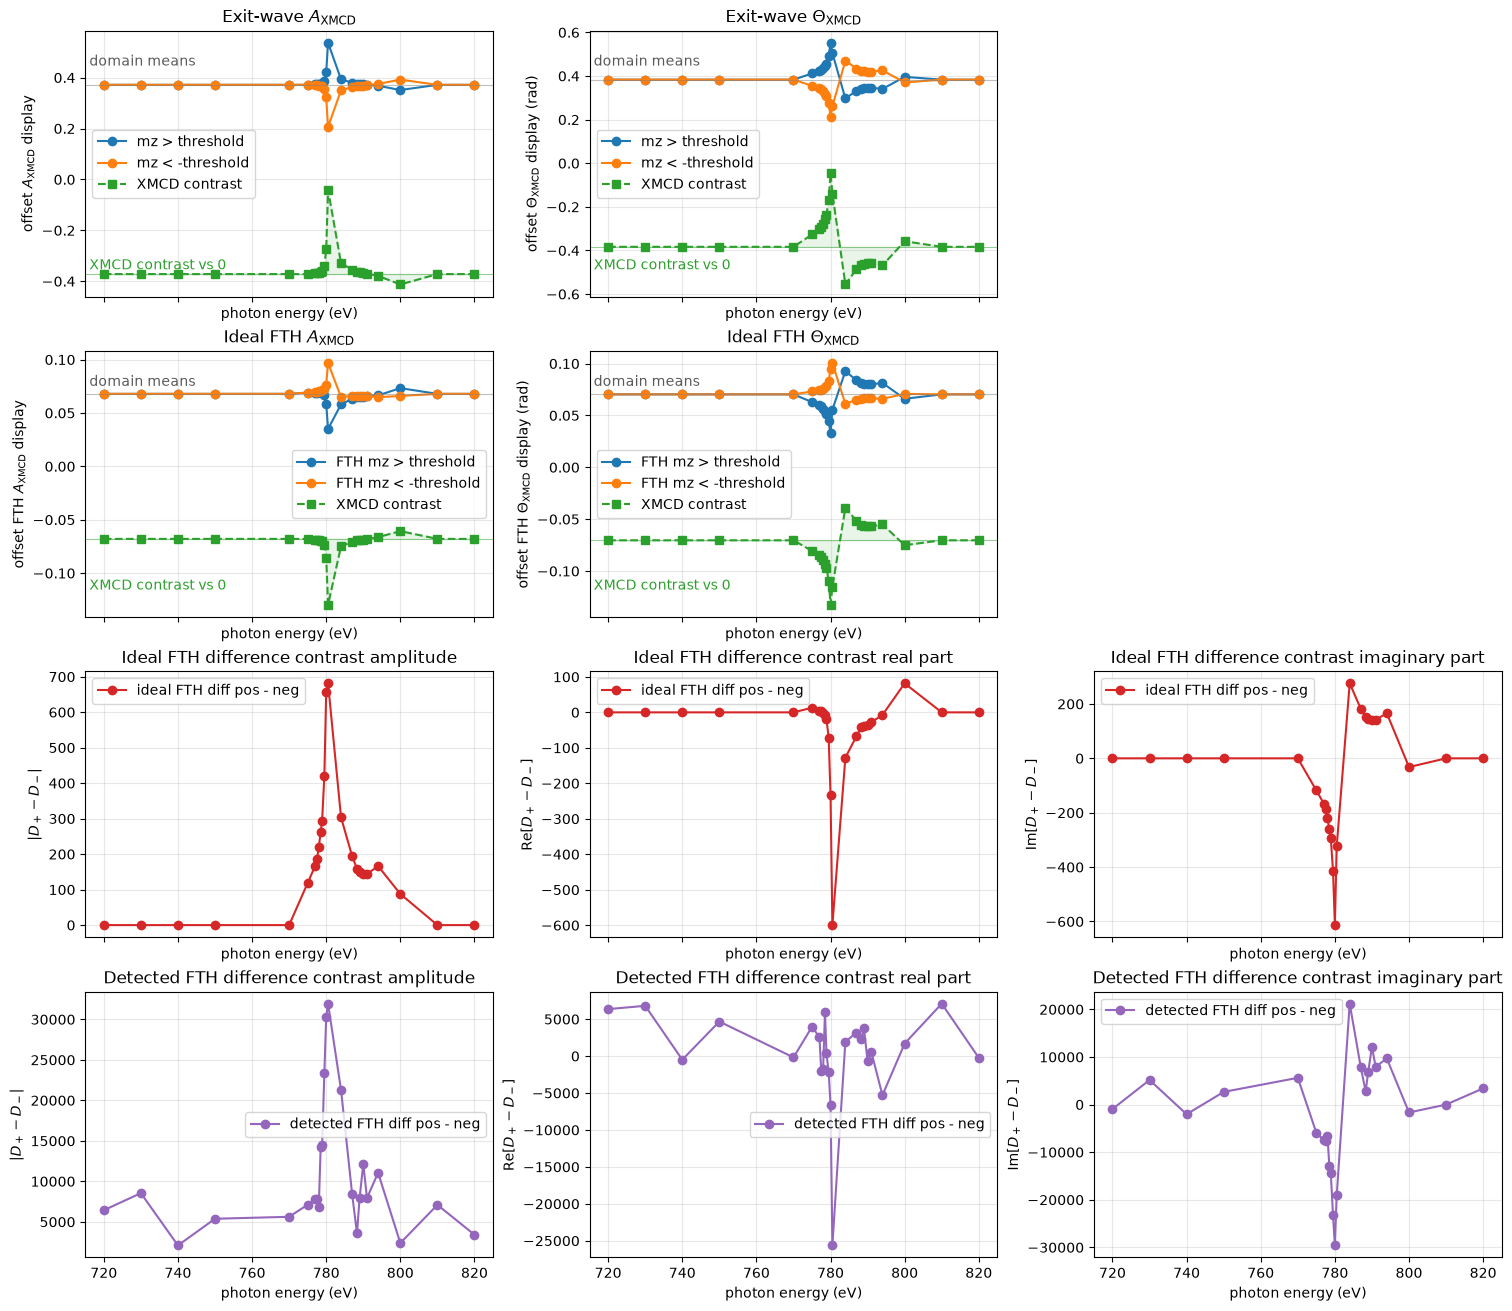

In [44]:
get_ipython().run_line_magic("matplotlib", "inline")

if energy_results:
    crop = sample_oh_slices
    mz_crop = magnetic_pattern_2d[crop]
    positive_domain = mz_crop > xmcd_domain_threshold
    negative_domain = mz_crop < -xmcd_domain_threshold

    if not np.any(positive_domain) or not np.any(negative_domain):
        raise ValueError(
            "Domain masks are empty. Lower xmcd_domain_threshold or check the magnetic pattern."
        )

    # Create circular aperture mask for real-space OH crop
    oh_index = aperture_types.index("OH")
    oh_radius_m = aperture_radii[oh_index]
    oh_radius_px = oh_radius_m / real_space_pixel_size
    
    # Center of crop in cropped coordinates
    crop_h, crop_w = mz_crop.shape
    cy_crop, cx_crop = crop_h // 2, crop_w // 2
    yy, xx = np.ogrid[:crop_h, :crop_w]
    oh_circular_mask = (yy - cy_crop)**2 + (xx - cx_crop)**2 <= oh_radius_px**2
    
    # Apply circular constraint to domain masks
    positive_domain = positive_domain & oh_circular_mask
    negative_domain = negative_domain & oh_circular_mask

    energies = np.array([result["energy_eV"] for result in energy_results])
    positive_ratio_mean = []
    negative_ratio_mean = []
    fth_positive_ratio_mean = []
    fth_negative_ratio_mean = []
    fth_positive_diff_mean = []
    fth_negative_diff_mean = []
    detected_fth_positive_diff_mean = []
    detected_fth_negative_diff_mean = []
    eps = 1e-30

    for result in energy_results:
        h = result["holograms"]

        cr_crop = frame_average(h.exit_waves[pols[0]])[crop]
        cl_crop = frame_average(h.exit_waves[pols[1]])[crop]
        ratio_crop = (cr_crop + eps) / (cl_crop + eps)
        positive_ratio_mean.append(np.nanmean(ratio_crop[positive_domain]))
        negative_ratio_mean.append(np.nanmean(ratio_crop[negative_domain]))

        fth_crop = result["recon_oh_slices"]
        reconstruction_pixel_size = float(result["reconstruction_pixel_size"])
        
        fth_cr = frame_average(h.reconstructions["ideal"][pols[0]])[fth_crop]
        fth_cl = frame_average(h.reconstructions["ideal"][pols[1]])[fth_crop]
        fth_diff = frame_average(h.reconstructions["ideal"]["diff"])[fth_crop]
        
        # Create circular aperture mask for FTH-space OH crop
        fth_oh_radius_px = oh_radius_m / reconstruction_pixel_size
        fth_crop_h, fth_crop_w = fth_cr.shape
        fth_cy_crop, fth_cx_crop = fth_crop_h // 2, fth_crop_w // 2
        fth_yy, fth_xx = np.ogrid[:fth_crop_h, :fth_crop_w]
        fth_oh_circular_mask = (fth_yy - fth_cy_crop)**2 + (fth_xx - fth_cx_crop)**2 <= fth_oh_radius_px**2
        
        # Resample domain masks and apply circular FTH mask
        positive_fth_domain = resample_nearest_to_shape(positive_domain, fth_cr.shape).astype(bool)
        negative_fth_domain = resample_nearest_to_shape(negative_domain, fth_cr.shape).astype(bool)
        positive_fth_domain = positive_fth_domain & fth_oh_circular_mask
        negative_fth_domain = negative_fth_domain & fth_oh_circular_mask

        fth_ratio_crop = (fth_cr + eps) / (fth_cl + eps)
        fth_positive_ratio_mean.append(np.nanmean(fth_ratio_crop[positive_fth_domain]))
        fth_negative_ratio_mean.append(np.nanmean(fth_ratio_crop[negative_fth_domain]))
        fth_positive_diff_mean.append(np.nanmean(fth_diff[positive_fth_domain]))
        fth_negative_diff_mean.append(np.nanmean(fth_diff[negative_fth_domain]))

        # Detected FTH reconstructions
        detected_fth_diff = frame_average(h.reconstructions["detected"]["diff"])[fth_crop]
        detected_fth_positive_diff_mean.append(np.nanmean(detected_fth_diff[positive_fth_domain]))
        detected_fth_negative_diff_mean.append(np.nanmean(detected_fth_diff[negative_fth_domain]))

    positive_ratio_mean = np.asarray(positive_ratio_mean)
    negative_ratio_mean = np.asarray(negative_ratio_mean)
    fth_positive_ratio_mean = np.asarray(fth_positive_ratio_mean)
    fth_negative_ratio_mean = np.asarray(fth_negative_ratio_mean)
    fth_positive_diff_mean = np.asarray(fth_positive_diff_mean)
    fth_negative_diff_mean = np.asarray(fth_negative_diff_mean)
    detected_fth_positive_diff_mean = np.asarray(detected_fth_positive_diff_mean)
    detected_fth_negative_diff_mean = np.asarray(detected_fth_negative_diff_mean)

    positive_mean = continuous_complex_log_ratio(
        positive_ratio_mean, np.ones_like(positive_ratio_mean)
    )
    negative_mean = continuous_complex_log_ratio(
        negative_ratio_mean, np.ones_like(negative_ratio_mean)
    )
    # Multiplicative domain contrast: compare the complex domain-averaged ratios.
    domain_contrast = continuous_complex_log_ratio(positive_ratio_mean, negative_ratio_mean)
    fth_positive_mean = continuous_complex_log_ratio(
        fth_positive_ratio_mean, np.ones_like(fth_positive_ratio_mean)
    )
    fth_negative_mean = continuous_complex_log_ratio(
        fth_negative_ratio_mean, np.ones_like(fth_negative_ratio_mean)
    )
    fth_domain_contrast = continuous_complex_log_ratio(
        fth_positive_ratio_mean, fth_negative_ratio_mean
    )
    fth_difference_contrast = fth_positive_diff_mean - fth_negative_diff_mean
    detected_fth_difference_contrast = detected_fth_positive_diff_mean - detected_fth_negative_diff_mean

    fig, axes = plt.subplots(4, 3, figsize=(15, 13), sharex=True)

    def plot_offset_xmcd_row(ax, domain_values, contrast_values, title, ylabel, domain_prefix=""):
        positive_values, negative_values = domain_values
        all_values = np.concatenate([
            np.ravel(positive_values),
            np.ravel(negative_values),
            np.ravel(contrast_values),
        ])
        span = np.nanmax(all_values) - np.nanmin(all_values)
        span = float(span if span > 0 else 1.0)
        domain_offset = 0.75 * span
        contrast_offset = -0.75 * span

        ax.plot(energies, positive_values + domain_offset, "o-", color="tab:blue", label=f"{domain_prefix}mz > threshold")
        ax.plot(energies, negative_values + domain_offset, "o-", color="tab:orange", label=f"{domain_prefix}mz < -threshold")
        ax.plot(energies, contrast_values + contrast_offset, "s--", color="tab:green", label="XMCD contrast")
        ax.fill_between(
            energies,
            contrast_offset,
            contrast_values + contrast_offset,
            color="tab:green",
            alpha=0.1,
        )
        ax.axhline(domain_offset, color="0.5", lw=0.8, alpha=0.5)
        ax.axhline(contrast_offset, color="tab:green", lw=0.8, alpha=0.5)
        ax.text(0.01, 0.91, "domain means", transform=ax.transAxes, color="0.35", va="top")
        ax.text(0.01, 0.09, "XMCD contrast vs 0", transform=ax.transAxes, color="tab:green", va="bottom")
        ax.set_title(title)
        ax.set_ylabel(ylabel)

    plot_offset_xmcd_row(
        axes[0, 0],
        (np.real(positive_mean), np.real(negative_mean)),
        np.real(domain_contrast),
        "Exit-wave $A_{\\mathrm{XMCD}}$",
        "offset $A_{\\mathrm{XMCD}}$ display",
    )
    plot_offset_xmcd_row(
        axes[0, 1],
        (np.imag(positive_mean), np.imag(negative_mean)),
        np.imag(domain_contrast),
        "Exit-wave $\\Theta_{\\mathrm{XMCD}}$",
        "offset $\\Theta_{\\mathrm{XMCD}}$ display (rad)",
    )

    plot_offset_xmcd_row(
        axes[1, 0],
        (np.real(fth_positive_mean), np.real(fth_negative_mean)),
        np.real(fth_domain_contrast),
        "Ideal FTH $A_{\\mathrm{XMCD}}$",
        "offset FTH $A_{\\mathrm{XMCD}}$ display",
        domain_prefix="FTH ",
    )
    plot_offset_xmcd_row(
        axes[1, 1],
        (np.imag(fth_positive_mean), np.imag(fth_negative_mean)),
        np.imag(fth_domain_contrast),
        "Ideal FTH $\\Theta_{\\mathrm{XMCD}}$",
        "offset FTH $\\Theta_{\\mathrm{XMCD}}$ display (rad)",
        domain_prefix="FTH ",
    )

    axes[2, 0].plot(
        energies,
        np.abs(fth_difference_contrast),
        "o-",
        color="tab:red",
        label="ideal FTH diff pos - neg",
    )
    axes[2, 1].plot(
        energies,
        np.real(fth_difference_contrast),
        "o-",
        color="tab:red",
        label="ideal FTH diff pos - neg",
    )
    axes[2, 2].plot(
        energies,
        np.imag(fth_difference_contrast),
        "o-",
        color="tab:red",
        label="ideal FTH diff pos - neg",
    )

    axes[3, 0].plot(
        energies,
        np.abs(detected_fth_difference_contrast),
        "o-",
        color="tab:purple",
        label="detected FTH diff pos - neg",
    )
    axes[3, 1].plot(
        energies,
        np.real(detected_fth_difference_contrast),
        "o-",
        color="tab:purple",
        label="detected FTH diff pos - neg",
    )
    axes[3, 2].plot(
        energies,
        np.imag(detected_fth_difference_contrast),
        "o-",
        color="tab:purple",
        label="detected FTH diff pos - neg",
    )

    blank_axes = [axes[0, 2], axes[1, 2]]
    for ax in blank_axes:
        ax.set_axis_off()

    axes[2, 0].set_title("Ideal FTH difference contrast amplitude")
    axes[2, 0].set_ylabel("$|D_+ - D_-|$")
    axes[2, 1].set_title("Ideal FTH difference contrast real part")
    axes[2, 1].set_ylabel("$\\mathrm{Re}[D_+ - D_-]$")
    axes[2, 2].set_title("Ideal FTH difference contrast imaginary part")
    axes[2, 2].set_ylabel("$\\mathrm{Im}[D_+ - D_-]$")

    axes[3, 0].set_title("Detected FTH difference contrast amplitude")
    axes[3, 0].set_ylabel("$|D_+ - D_-|$")
    axes[3, 1].set_title("Detected FTH difference contrast real part")
    axes[3, 1].set_ylabel("$\\mathrm{Re}[D_+ - D_-]$")
    axes[3, 2].set_title("Detected FTH difference contrast imaginary part")
    axes[3, 2].set_ylabel("$\\mathrm{Im}[D_+ - D_-]$")

    for ax in axes.ravel():
        if ax in blank_axes:
            continue
        ax.set_xlabel("photon energy (eV)")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")


    print(f"Positive-domain pixels in exit-wave OH crop: {np.count_nonzero(positive_domain)}")
    print(f"Negative-domain pixels in exit-wave OH crop: {np.count_nonzero(negative_domain)}")
else:
    print("No sweep results available yet.")


plt.show()


## 12. Things To Try

- Increase `energy_values_eV` density around 777 to 780 eV for a finer Co L3 scan.
- Add more points around 792 to 795 eV for the Co L2 edge.
- Set `propagate=True` to compare Jones-only and multislice energy dependence.
- Switch `propagator_method="Scalar"` when you want a faster eigenmode-style approximation.
- Increase `detector_shape` once the notebook behavior is clear.



## 13. Saved Energy Sweep

The sweep streams and flushes every completed energy to HDF5, preserving every generated detector frame. Each run creates a new file: `cobalt_l_edge_energy_sweep.h5`, then `_001.h5`, `_002.h5`, and so on. Existing files, including interrupted runs, are never overwritten.

`HDF5_BASE_PATH` controls the output directory and base filename. `HDF5_OUTPUT_PATH` records the actual file for the current run. To load an earlier run, set `RUN_ENERGY_SWEEP=False` and set `HDF5_OUTPUT_PATH` to that file before executing the sweep cell.


In [45]:
# Results are already saved by the sweep cell.
print(f"Sweep output: {HDF5_OUTPUT_PATH.resolve()}")


Sweep output: /home/riccardo/Desktop/Github/Data/fomocid/12_cobalt_l_edge_energy_sweep/cobalt_l_edge_energy_sweep_003.h5
